# Modelado — Riesgo de retraso por franja de itinerario

**Entrega 2 · Micro-proyecto Desarrollo de Soluciones · MAIA**

Este notebook entrena y compara tres familias de modelos para responder la pregunta de negocio,
replanteada a partir de la retroalimentación de la Entrega 1:

> *¿Qué combinaciones de aerolínea, ruta, día y franja horaria concentran el mayor riesgo de
> retraso, de modo que el equipo de planeación pueda reforzar recursos y ajustar márgenes de
> conexión en los itinerarios más expuestos?*

**Por qué cambió el encuadre.** Con aerolínea, ruta, día, hora y duración no se estima el riesgo de
un vuelo concreto de mañana: se estima el riesgo de una **franja de itinerario que se repite igual
todas las semanas**. Eso no da para una alerta operativa del día, pero sí para una herramienta de
**planeación**: decidir qué franjas conviene reforzar con personal y qué conexiones necesitan más
margen. El usuario es el equipo de planeación de red, el momento es la construcción del itinerario
estacional, y la decisión es dónde poner recursos limitados.

**Enfoque.** Se ejecutan **30 experimentos por familia (90 en total)** con búsqueda aleatoria de
hiperparámetros, todos registrados en MLflow. La selección se hace sobre un bloque de validación
temporal; el bloque de prueba se reserva y solo se toca una vez, con los tres finalistas.

**Lo que condiciona todas las decisiones de este notebook** es el hallazgo del EDA: el dataset tiene
deriva temporal fuerte, la tasa de retraso pasa de 34,5% a 51,6% en 31 días. Eso obliga a partición
temporal, cambia qué métrica sirve para comparar y hace de la calibración un problema de primer
orden.

**Sobre el techo del problema.** El dataset proviene de un flujo de datos donde el orden de las
filas cargaba la marca temporal. Al perderse, se perdió con ella la variable más predictiva del
problema: si la aeronave venía retrasada de su vuelo anterior. La sección 12 pone a prueba si el
número de vuelo sirve como sustituto de ese efecto.

## 1. Configuración

### 1.1 Arranque: local o Google Colab

La celda siguiente detecta dónde se ejecuta el notebook y prepara el entorno. En local no hace nada:
asume el repositorio clonado y el entorno instalado. En Colab clona el repositorio, instala
dependencias y **reconstruye el dataset desde OpenML**, porque `data/airlines.csv` se versiona con
DVC y no viaja en Git.

Para registrar los experimentos en el servidor del equipo basta escribir la IP en el campo
`MLFLOW_TRACKING_URI`. Si se deja vacío, MLflow usa SQLite local y el notebook corre igual.

In [1]:
import os
import sys
from pathlib import Path

EN_COLAB = "google.colab" in sys.modules

#@markdown Servidor de MLflow, por ejemplo http://54.1.2.3:5000 — vacio usa SQLite local
MLFLOW_TRACKING_URI = "http://54.173.162.16:5000"  #@param {type:"string"}
if MLFLOW_TRACKING_URI.strip():
    os.environ["MLFLOW_TRACKING_URI"] = MLFLOW_TRACKING_URI.strip()

if EN_COLAB:
    REPOSITORIO = "https://github.com/santiagoMeloMedina/microproyecto-grupo4-pds-maia.git"
    RAMA = "feature/katherin-modelos-entrega2"
    RAIZ = Path("/content/microproyecto-grupo4-pds-maia")
    ZIP = Path("/content/proyecto.zip")

    if not RAIZ.exists():
        if ZIP.exists():
            # Codigo subido a mano: sirve cuando la rama todavia no se ha
            # publicado en GitHub.
            import zipfile
            with zipfile.ZipFile(ZIP) as z:
                z.extractall("/content")
            print("Codigo extraido de proyecto.zip")
        else:
            !git clone -q --branch {RAMA} {REPOSITORIO} {RAIZ}
            print("Codigo clonado de GitHub")

    # Colab arranca con numpy y pandas ya importados. Si el pip los actualiza,
    # el kernel se queda con las extensiones en C de la version anterior y el
    # siguiente import falla con "cannot import name '_slice' from
    # numpy._core.umath". La unica salida es reiniciar el kernel; despues del
    # reinicio las versiones ya coinciden y esta rama no se vuelve a activar.
    import importlib.metadata as _md

    def _version(paquete):
        try:
            return _md.version(paquete)
        except _md.PackageNotFoundError:
            return None

    CRITICOS = ["numpy", "pandas", "scikit-learn", "xgboost"]
    _antes = {p: _version(p) for p in CRITICOS}

    %pip install -q --progress-bar off -r {RAIZ}/modeling/requirements.txt

    _cambiados = [p for p in CRITICOS if _version(p) != _antes[p]]
    if _cambiados:
        print("Se actualizaron:", ", ".join(_cambiados))
        print("Reiniciando el entorno. Cuando termine, vuelve a ejecutar todo")
        print("(Entorno de ejecucion -> Ejecutar todo). Nada se pierde.")
        import IPython

        IPython.Application.instance().kernel.do_shutdown(True)

    # El CSV no esta en Git porque lo versiona DVC. Se reconstruye desde el ARFF
    # publico de OpenML, que produce un archivo identico byte a byte al que
    # apunta data/airlines.csv.dvc y no necesita credenciales de AWS.
    CSV = RAIZ / "data" / "airlines.csv"
    if not CSV.exists():
        !wget -q -O /tmp/airlines.arff https://openml.org/data/v1/download/66526/airlines.arff
        !python {RAIZ}/scripts/windows/rebuild_dataset.py /tmp/airlines.arff {CSV}
else:
    RAIZ = Path.cwd().parent

sys.path.insert(0, str(RAIZ))

# Resumen de estado: si algo de esto no es lo esperado, conviene detenerse aqui
# en vez de descubrirlo cuarenta minutos despues.
import shutil
import subprocess


def _gpu_visible():
    if not shutil.which("nvidia-smi"):
        return None
    try:
        salida = subprocess.run(["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
                                capture_output=True, text=True, timeout=20)
        if salida.returncode == 0 and salida.stdout.strip():
            return salida.stdout.strip().splitlines()[0]
    except Exception:
        pass
    return None


_csv = RAIZ / "data" / "airlines.csv"
_uri = os.environ.get("MLFLOW_TRACKING_URI")
_gpu = _gpu_visible()

print()
print("=" * 60)
print(f"  Entorno    : {'Google Colab' if EN_COLAB else 'local'}")
print(f"  Proyecto   : {RAIZ}")
print(f"  Dataset    : {'OK, ' + f'{_csv.stat().st_size / 1024**2:.1f} MB' if _csv.exists() else 'FALTA'}")
print(f"  MLflow     : {_uri or 'SQLite local (no se indico IP del servidor)'}")
print(f"  GPU        : {_gpu or 'no detectada -> XGBoost usara CPU'}")
print("=" * 60)
if not _uri:
    print("  Aviso: sin MLFLOW_TRACKING_URI los experimentos quedan en esta")
    print("         maquina y se pierden al cerrar la sesion de Colab.")
if EN_COLAB and not _gpu:
    print("  Aviso: activa la GPU en Entorno de ejecucion -> Cambiar tipo.")


  Entorno    : Google Colab
  Proyecto   : /content/microproyecto-grupo4-pds-maia
  Dataset    : OK, 18.3 MB
  MLflow     : http://54.173.162.16:5000
  GPU        : Tesla T4


### 1.2 Dependencias

El código de preparación de datos vive en el paquete `airlines_ml/`, que comparten este notebook y
el tablero. Mantenerlo fuera del notebook garantiza que el modelo reciba al servir exactamente las
mismas columnas con las que se entrenó, que es la causa más común de que un modelo empaquetado
prediga distinto al desplegarse.

`N_EXPERIMENTOS` fija el tamaño de la búsqueda: 30 por familia, 90 en total.

In [2]:
import io
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve
from sklearn.pipeline import Pipeline

from airlines_ml import baselines, modeling, tracking
from airlines_ml.data import OBJETIVO, cargar_particionado
from airlines_ml.features import CAMPOS_ENTRADA, construir_preprocesador

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

N_EXPERIMENTOS = 30      # por familia; 3 familias => 90 corridas
mlflow.autolog(disable=True)

uri = tracking.configurar("airlines-retrasos")
print("MLflow tracking URI:", uri)
print("Servidor remoto   :", tracking.es_remoto())

# XGBoost usa GPU si hay una visible. Acelera el entrenamiento, no cambia el
# desempeno: sobre estos datos el AUC sale identico en CPU y en GPU.
print("Dispositivo XGBoost:", modeling.dispositivo_xgboost())

# Las figuras que sostienen afirmaciones del reporte se guardan en disco para
# poder insertarlas alli sin recortar pantallazos del notebook.
FIGURAS = RAIZ / "docs" / "2nd_delivery" / "images"
FIGURAS.mkdir(parents=True, exist_ok=True)

def guardar(figura, nombre):
    ruta = FIGURAS / nombre
    figura.savefig(ruta, dpi=150, bbox_inches="tight")
    print(f"figura guardada: docs/2nd_delivery/images/{nombre}")

2026/09/05 15:45:49 INFO mlflow.tracking.fluent: Experiment with name 'airlines-retrasos' does not exist. Creating a new experiment.


MLflow tracking URI: http://54.173.162.16:5000
Servidor remoto   : True
Dispositivo XGBoost: cuda


Si la variable `MLFLOW_TRACKING_URI` no está definida, MLflow escribe en `./mlruns` y el notebook
corre igual. Para consolidar los resultados en el servidor del equipo basta exportarla antes de
abrir Jupyter; el resto del notebook no cambia. El montaje del servidor en EC2 está documentado en
[`docs/2nd_delivery/mlflow_ec2.md`](../docs/2nd_delivery/mlflow_ec2.md).

## 2. Datos y partición temporal

La partición es **temporal y no aleatoria**. El bloque de validación sirve para elegir
hiperparámetros y umbral; el de prueba queda intacto hasta la evaluación final.

In [3]:
particion = cargar_particionado()
resumen = particion.resumen()
resumen["Tasa de retraso"] = resumen["Tasa de retraso"].map("{:.2%}".format)
resumen

,Particion,Dias,Filas,Tasa de retraso
0,Entrenamiento,0-19,347091,41.00%
1,Validacion,20-24,84824,48.14%
2,Prueba,25-30,107464,53.14%


La tasa de retraso sube de forma monótona entre los tres bloques. Esa es la deriva, y explica por
qué una partición aleatoria estratificada —que fue lo que se propuso en la Entrega 1— daría
métricas optimistas: repartiría los mismos días entre entrenamiento y prueba, y el modelo estaría
evaluándose sobre un período que ya conoce.

In [4]:
entrena, valida, prueba = particion.entrenamiento, particion.validacion, particion.prueba
y_entrena = entrena[OBJETIVO].to_numpy()
y_valida = valida[OBJETIVO].to_numpy()
y_prueba = prueba[OBJETIVO].to_numpy()

print(f"Entrenamiento {len(entrena):>7,} filas   dias 0-19")
print(f"Validacion    {len(valida):>7,} filas   dias 20-24")
print(f"Prueba        {len(prueba):>7,} filas   dias 25-30")

Entrenamiento 347,091 filas   dias 0-19
Validacion     84,824 filas   dias 20-24
Prueba        107,464 filas   dias 25-30


### Panorama descriptivo

Antes de modelar conviene ver el riesgo tal como lo verá el equipo de planeación: **tasa de retraso
junto al volumen de cada grupo**. Una tasa alta sobre 300 vuelos no merece la misma atención que una
tasa alta sobre 90.000, y una matriz de correlación no muestra nada de esto porque cinco de las
siete variables son categóricas.

Estas cuatro vistas son exactamente las que alimentan el tablero.

figura guardada: docs/2nd_delivery/images/modelo_01_panorama.png


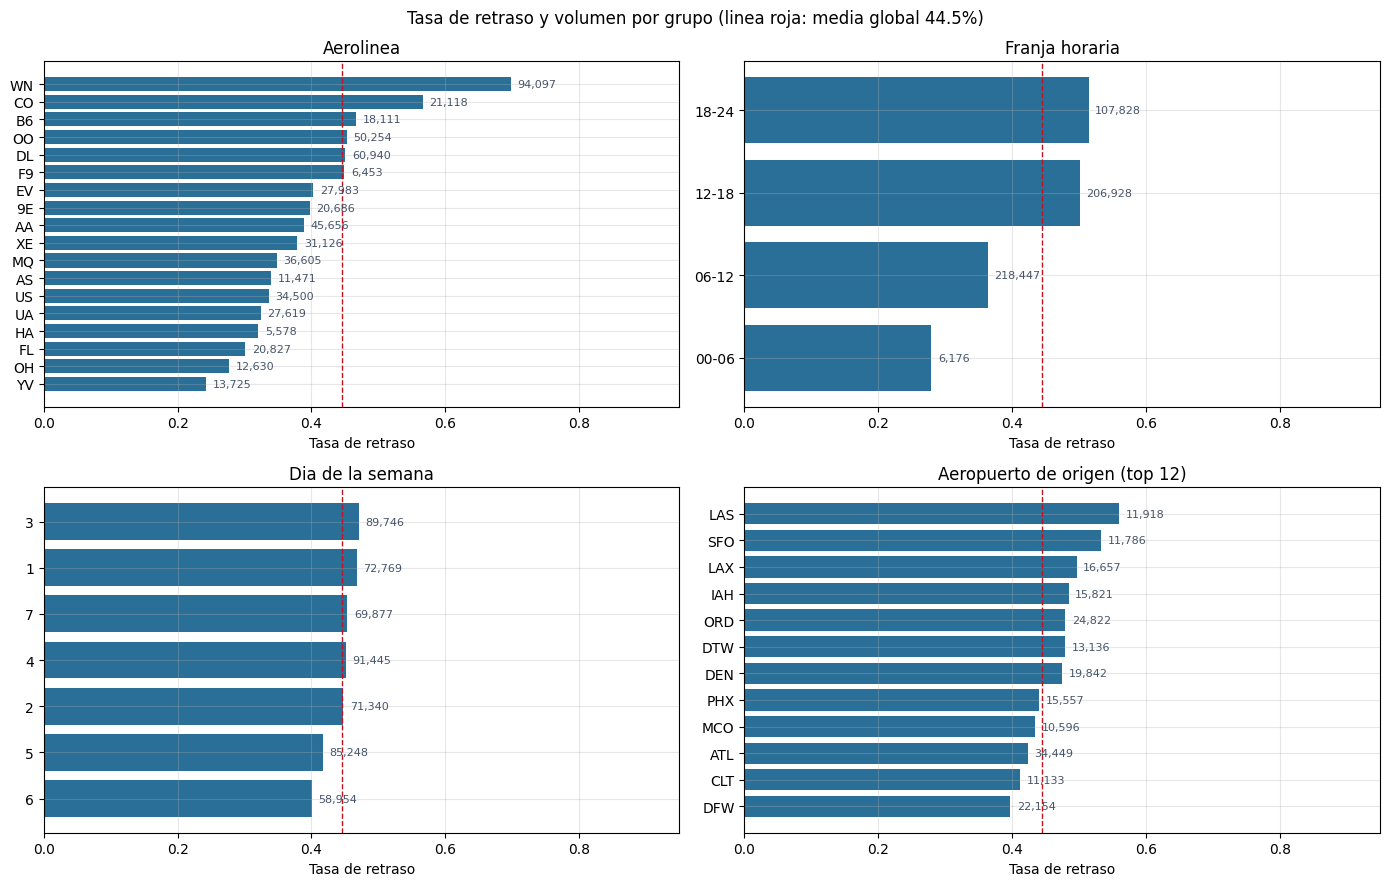

In [5]:
from airlines_ml.features import agregar_derivadas

panorama = agregar_derivadas(
    pd.concat([particion.entrenamiento_completo, prueba], ignore_index=True)
)
tasa_global = panorama[OBJETIVO].mean()

vistas = [
    ("Airline", "Aerolinea", None),
    ("Franja", "Franja horaria", None),
    ("DayOfWeek", "Dia de la semana", None),
    ("AirportFrom", "Aeropuerto de origen (top 12)", 12),
]

fig, ejes = plt.subplots(2, 2, figsize=(14, 9))
for eje, (columna, titulo, tope) in zip(ejes.flat, vistas):
    resumen = (panorama.groupby(columna, observed=True)[OBJETIVO]
               .agg(tasa="mean", vuelos="size").sort_values("tasa", ascending=False))
    if tope:
        resumen = resumen.nlargest(tope, "vuelos").sort_values("tasa", ascending=False)

    posiciones = np.arange(len(resumen))
    eje.barh(posiciones, resumen["tasa"], color="#2A6F97")
    eje.axvline(tasa_global, color="#C1121F", linestyle="--", linewidth=1)
    eje.set_yticks(posiciones)
    eje.set_yticklabels(resumen.index)
    eje.invert_yaxis()
    eje.set(title=titulo, xlabel="Tasa de retraso", xlim=(0, 0.95))

    # El volumen va al lado de cada barra: sin el, una tasa alta sobre pocos
    # vuelos parece tan accionable como una sobre decenas de miles.
    for y, (tasa, vuelos) in enumerate(zip(resumen["tasa"], resumen["vuelos"])):
        eje.text(tasa + 0.01, y, f"{vuelos:,.0f}", va="center", fontsize=8, color="#475569")

fig.suptitle(f"Tasa de retraso y volumen por grupo (linea roja: media global {tasa_global:.1%})")
plt.tight_layout()
guardar(fig, "modelo_01_panorama.png")
plt.show()

Se lee de inmediato lo que la correlación no alcanza a mostrar: WN concentra a la vez la tasa más
alta **y** el mayor volumen, lo que la convierte en la prioridad evidente de refuerzo; las franjas
tardías duplican a las de madrugada; y entre los aeropuertos de origen de mayor tráfico la
dispersión es amplia. El número al lado de cada barra es el volumen, y es lo que separa un hallazgo
accionable de una curiosidad estadística.

## 3. Líneas base

Antes de entrenar nada se fija el piso. Un modelo solo se justifica si supera a la regla simple que
un analista escribiría a mano.

In [6]:
# Las lineas base reciben exactamente el mismo trato que los modelos: se ajustan
# en entrenamiento, fijan umbral en validacion y se reajustan sobre 0-24 antes de
# medirse en prueba. Compararlas a umbral 0,5 fijo las dejaria en desventaja
# artificial y volveria optimista cualquier conclusion sobre los modelos.
filas_base = []
entrena_completo = particion.entrenamiento_completo

for clase in baselines.LINEAS_BASE:
    umbral = modeling.elegir_umbral(y_valida, clase().fit(entrena).predict_proba(valida))
    base = clase().fit(entrena_completo)
    metricas = modeling.evaluar(y_prueba, base.predict_proba(prueba), umbral)
    filas_base.append({"Linea base": base.nombre, **metricas})

tabla_base = pd.DataFrame(filas_base).set_index("Linea base")
tabla_base[["roc_auc", "accuracy", "precision", "recall", "f1", "brier", "umbral"]].round(4)

,roc_auc,accuracy,precision,recall,f1,brier,umbral
Linea base,,,,,,,
base_clase_mayoritaria,0.5000,0.5314,0.5314,1.0000,0.6940,0.2605,0.20
base_memoria_itinerario,0.6043,0.5957,0.5965,0.7393,0.6603,0.3450,0.20
base_aerolinea_franja,0.6763,0.5946,0.5797,0.8624,0.6933,0.2352,0.29


`base_clase_mayoritaria` tiene AUC 0,5 por construcción (predice una constante) y su accuracy queda
**por debajo del azar**: aprendió que la clase dominante era "sin retraso" y en el período de prueba
la mayoría de vuelos sí se retrasa. Es la demostración más directa de que la deriva importa.

La referencia real a superar es `base_aerolinea_franja`.

## 4. Modelos candidatos

Se eligen tres familias, alineadas con lo que el equipo declaró en la Entrega 1 (§2.3.4) y con la
literatura citada, donde los métodos basados en árboles resultan competitivos para este problema:

| Familia | Rol | Preprocesamiento |
|---|---|---|
| **Regresión logística** | Modelo base interpretable. Da coeficientes que se pueden explicar a operaciones. | One-hot disperso + escalado |
| **Random Forest** | Captura interacciones sin necesidad de especificarlas. Robusto a hiperparámetros. | Codificación ordinal |
| **XGBoost** | Boosting sobre histogramas, con soporte nativo de categóricas. | dtype `category` |

**Sobre el preprocesamiento.** Las categóricas nominales son de alta cardinalidad: 18 aerolíneas,
293 aeropuertos de origen, 293 de destino y 4.190 rutas. XGBoost con `enable_categorical` hace
particiones de conjunto sobre ellas, en vez de imponerles el orden artificial que introduce una
codificación ordinal. Para la regresión logística se excluye `Ruta` del one-hot: sus 4.190 niveles
dispararían la dimensionalidad sin aportar sobre `Airline` y los dos aeropuertos, que ya están.

### Variables construidas

Todas deben poder calcularse con los seis campos que el tablero pide al usuario. Una variable que
dependa del día calendario concreto sería imposible de construir al servir una predicción.

| Variable | Motivación |
|---|---|
| `Hora`, `TimeSin`, `TimeCos` | La hora es cíclica: 23:50 y 00:10 distan 20 minutos, no 23 horas. |
| `Franja` | Discretiza el efecto de propagación de retrasos a lo largo del día. |
| `Ruta` | El par origen–destino discrimina entre 19,0% y 68,0% en rutas frecuentes. |
| `DensidadOrigen`, `DensidadDestino` | Proxy de congestión: cuántos vuelos suele haber en ese aeropuerto ese día y esa hora. Se aprende como tabla de consulta en entrenamiento, así que está disponible antes del despegue. |

`Flight` se excluye. Es un identificador, no una magnitud; su correlación de -0,34 con `Length` es
un artefacto de cómo las aerolíneas numeran sus vuelos.

## 5. Métricas de evaluación

La elección de métrica no es neutral bajo deriva temporal.

| Métrica | Para qué | Por qué aquí |
|---|---|---|
| **ROC-AUC** | Criterio principal de selección | Mide ordenamiento y es **invariante a la tasa base**. Como la tasa se desplaza de 41% a 53% entre bloques, cualquier métrica atada a un umbral se mueve por razones ajenas a la calidad del modelo. |
| **PR-AUC** | Complemento | Se concentra en la clase positiva, que es la accionable para operaciones. |
| **Brier / log-loss** | Calibración | El tablero muestra *"Alto riesgo · 74%"*. Ese número tiene que significar lo que dice, no solo ordenar bien. |
| **Accuracy, Precision, Recall, F1** | Comportamiento operativo | Se reportan al umbral elegido en validación, nunca en prueba. |

El umbral se fija maximizando F1 sobre validación. Dejarlo en 0,5 sería arbitrario: con la tasa base
en movimiento, 0,5 no corresponde a ningún punto de operación defendible.

## 6. Búsqueda de hiperparámetros

Se recorre el espacio por **muestreo aleatorio** y no por malla exhaustiva: con seis o siete
hiperparámetros una malla obligaría a miles de combinaciones, mientras que 30 muestras cubren mejor
el espacio con el presupuesto disponible. La semilla es fija, así que la búsqueda es reproducible.

El preprocesador se ajusta **una vez por familia** y se reutiliza en las 30 corridas. Lo que cambia
entre corridas son los hiperparámetros del clasificador, no la codificación, así que reajustarlo
sería trabajo repetido. El modelo finalista sí se reconstruye después como pipeline completo, que es
el artefacto que se empaqueta.

Primero se ajusta el preprocesador de cada familia y se guarda la matriz resultante. El número de
columnas de cada una muestra por qué el preprocesamiento no puede ser el mismo para las tres: la
regresión logística acaba con 600 columnas por el one-hot, mientras que los modelos de árboles
trabajan con 13, porque manejan las categóricas sin expandirlas.

In [7]:
matrices = {}
for familia in modeling.FAMILIAS.values():
    t0 = time.time()
    pre = construir_preprocesador(familia.preprocesamiento)
    X_tr = pre.fit_transform(entrena, y_entrena)
    X_va = pre.transform(valida)
    matrices[familia.nombre] = (X_tr, X_va)
    print(f"{familia.nombre:14} {familia.preprocesamiento:11} "
          f"{X_tr.shape[1]:>4} columnas   {time.time() - t0:.1f}s")

logistica      lineal       600 columnas   2.2s
random_forest  ordinal       13 columnas   1.6s
xgboost        categorico    13 columnas   2.7s


El bucle siguiente es el núcleo del notebook. Por cada una de las 90 combinaciones abre una corrida
en MLflow y registra:

- **Etiquetas** (`familia`, `etapa`, `preprocesamiento`, `particion`), que permiten filtrar después
  en la UI sin tener que recordar qué era cada corrida.
- **Parámetros**: los hiperparámetros muestreados.
- **Métricas**: las nueve de validación más el umbral elegido y el tiempo de ajuste.

Registrar el tiempo junto al desempeño es lo que permite después decidir entre dos modelos que
empatan en AUC. Los artefactos no se suben aquí: 90 modelos serializados llenarían el servidor sin
aportar nada, y solo el ganador se registra (sección 14).

In [8]:
registros = []

for familia in modeling.FAMILIAS.values():
    X_tr, X_va = matrices[familia.nombre]
    configuraciones = modeling.muestrear_configuraciones(familia.nombre, N_EXPERIMENTOS)
    print(f"\n=== {familia.nombre}: {len(configuraciones)} experimentos ===")

    for i, params in enumerate(configuraciones, start=1):
        with mlflow.start_run(run_name=f"{familia.nombre}-{i:02d}"):
            t0 = time.time()
            modelo = familia.constructor(**dict(params))
            modelo.fit(X_tr, y_entrena)
            segundos = time.time() - t0

            proba_va = modelo.predict_proba(X_va)[:, 1]
            umbral = modeling.elegir_umbral(y_valida, proba_va)
            metricas = modeling.evaluar(y_valida, proba_va, umbral)

            mlflow.set_tags({
                "familia": familia.nombre,
                "etapa": "busqueda",
                "preprocesamiento": familia.preprocesamiento,
                "particion": "entrena 0-19 / valida 20-24",
            })
            mlflow.log_params(modeling.params_para_registro(params))
            mlflow.log_metrics({**metricas, "segundos_ajuste": segundos})

            registros.append({
                "familia": familia.nombre,
                "corrida": i,
                "segundos": segundos,
                **modeling.params_para_registro(params),
                **metricas,
            })

        if i % 10 == 0:
            print(f"  {i:>2}/{len(configuraciones)}  mejor AUC hasta ahora: "
                  f"{max(r['roc_auc'] for r in registros if r['familia'] == familia.nombre):.4f}")

resultados = pd.DataFrame(registros)
print(f"\nTotal de corridas registradas en MLflow: {len(resultados)}")


=== logistica: 30 experimentos ===
🏃 View run logistica-01 at: http://54.173.162.16:5000/#/experiments/1/runs/798193169ec94fcb88cb66738debcf36
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1
🏃 View run logistica-02 at: http://54.173.162.16:5000/#/experiments/1/runs/46cd238d7ce843259a6cd3a44b11f355
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1
🏃 View run logistica-03 at: http://54.173.162.16:5000/#/experiments/1/runs/559f055f4a2c4391ac9aeeedcdd1fad3
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1
🏃 View run logistica-04 at: http://54.173.162.16:5000/#/experiments/1/runs/4f2ea2abc85744c3a1cc6c80961d010d
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1
🏃 View run logistica-05 at: http://54.173.162.16:5000/#/experiments/1/runs/3d632bf045784342bcf73b20ef3903de
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1
🏃 View run logistica-06 at: http://54.173.162.16:5000/#/experiments/1/runs/54877ba1baa043c3962ec28452851

🏃 View run logistica-15 at: http://54.173.162.16:5000/#/experiments/1/runs/60076daa656b422291e0d9e7f2586b08
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1
🏃 View run logistica-16 at: http://54.173.162.16:5000/#/experiments/1/runs/96f9e4b0fb1849098df3e04e4ba444c4
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1
🏃 View run logistica-17 at: http://54.173.162.16:5000/#/experiments/1/runs/4ed0a1acb2a844cd844db18281adead9
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1
🏃 View run logistica-18 at: http://54.173.162.16:5000/#/experiments/1/runs/6164031d57b646f795bd5b5f2b0a29e9
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1


🏃 View run logistica-19 at: http://54.173.162.16:5000/#/experiments/1/runs/4977769a8c5542cba858a768567a81a7
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1
🏃 View run logistica-20 at: http://54.173.162.16:5000/#/experiments/1/runs/5f2929cfcc8d42ba888b6f3097425787
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1
  20/30  mejor AUC hasta ahora: 0.6906
🏃 View run logistica-21 at: http://54.173.162.16:5000/#/experiments/1/runs/b0bfa3a94dbe4794affe370a5458e4f4
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1
🏃 View run logistica-22 at: http://54.173.162.16:5000/#/experiments/1/runs/da4e8b42456d4653879b56e314cb35b0
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1
🏃 View run logistica-23 at: http://54.173.162.16:5000/#/experiments/1/runs/775a187e64964b1caad31d275a1b624c
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1
🏃 View run logistica-24 at: http://54.173.162.16:5000/#/experiments/1/runs/edd5eda80c2740f0999cc2b9ec

## 7. Resultados de la búsqueda

In [9]:
comparativa = (resultados.groupby("familia")["roc_auc"]
               .agg(Corridas="size", AUC_min="min", AUC_mediana="median", AUC_max="max")
               .sort_values("AUC_max", ascending=False))
comparativa.round(4)

,Corridas,AUC_min,AUC_mediana,AUC_max
familia,,,,
xgboost,30,0.6862,0.6996,0.7075
random_forest,30,0.6633,0.6992,0.7073
logistica,30,0.6762,0.6901,0.6906


figura guardada: docs/2nd_delivery/images/modelo_02_dispersion_auc.png


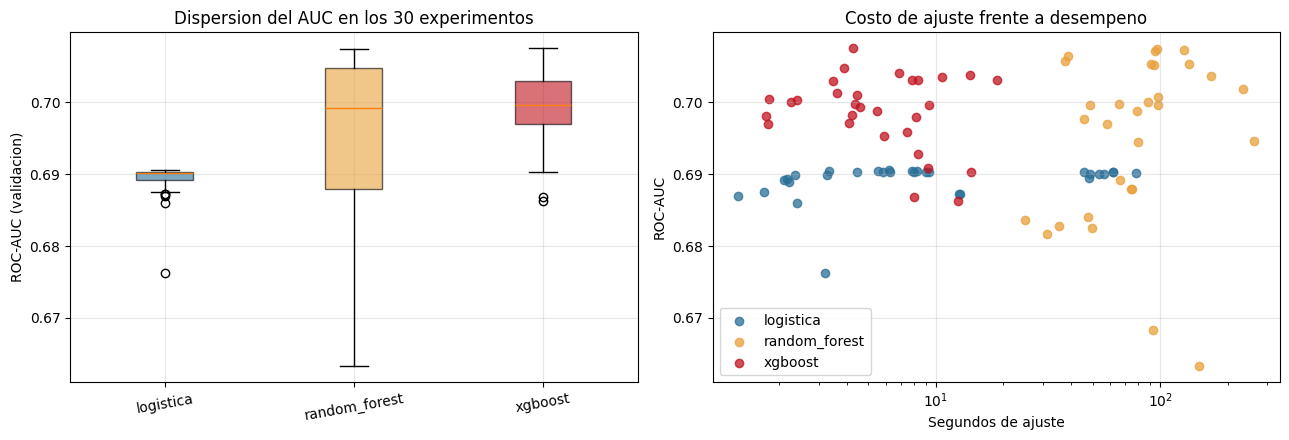

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

familias = list(modeling.FAMILIAS)
colores = {"logistica": "#2A6F97", "random_forest": "#E9A03B", "xgboost": "#C1121F"}

datos_caja = [resultados.loc[resultados.familia == f, "roc_auc"] for f in familias]
caja = axes[0].boxplot(datos_caja, patch_artist=True)
for parche, f in zip(caja["boxes"], familias):
    parche.set_facecolor(colores[f])
    parche.set_alpha(0.6)
axes[0].set_xticks(range(1, len(familias) + 1))
axes[0].set_xticklabels(familias, rotation=10)
axes[0].set(title="Dispersion del AUC en los 30 experimentos", ylabel="ROC-AUC (validacion)")

for f in familias:
    sub = resultados[resultados.familia == f]
    axes[1].scatter(sub["segundos"], sub["roc_auc"], label=f, color=colores[f], alpha=0.75)
axes[1].set(title="Costo de ajuste frente a desempeno", xlabel="Segundos de ajuste", ylabel="ROC-AUC")
axes[1].set_xscale("log")
axes[1].legend()

plt.tight_layout()
guardar(fig, "modelo_02_dispersion_auc.png")
plt.show()

La caja de la izquierda muestra qué tan sensible es cada familia a sus hiperparámetros: una caja
alta significa que la elección importa mucho. La derecha sitúa el costo: si dos familias empatan en
AUC, la más barata de ajustar es preferible para el reentrenamiento periódico que la deriva exige.

La mejor configuración de cada familia, que es la que pasa a la evaluación final:

In [11]:
mejores = (resultados.sort_values("roc_auc", ascending=False)
           .groupby("familia", as_index=False).first())
columnas = ["familia", "corrida", "roc_auc", "pr_auc", "brier", "f1", "umbral", "segundos"]
mejores[columnas].sort_values("roc_auc", ascending=False).round(4)

,familia,corrida,roc_auc,pr_auc,brier,f1,umbral,segundos
2,xgboost,17,0.7075,0.6949,0.2241,0.6760,0.27,4.2607
1,random_forest,3,0.7073,0.6984,0.2160,0.6761,0.32,97.0314
0,logistica,13,0.6906,0.6800,0.2213,0.6707,0.29,6.1704


## 8. Finalistas: reajuste y evaluación en prueba

Los tres ganadores se reentrenan sobre **entrenamiento + validación** (días 0–24) y se evalúan una
sola vez sobre el bloque de prueba (días 25–30). El umbral es el que cada uno fijó en validación: no
se reoptimiza sobre prueba, porque eso sería ajustar al conjunto que se quiere medir.

Aquí sí se construye el **pipeline completo** —preprocesamiento y clasificador en un solo objeto—
que es lo que se registra en MLflow y lo que consumirá la API.

In [12]:
finalistas = {}
filas_prueba = []
y_completo = entrena_completo[OBJETIVO].to_numpy()

for _, fila in mejores.iterrows():
    familia = modeling.FAMILIAS[fila["familia"]]
    params = dict(modeling.muestrear_configuraciones(familia.nombre, N_EXPERIMENTOS)[int(fila["corrida"]) - 1])
    umbral = float(fila["umbral"])

    with mlflow.start_run(run_name=f"final-{familia.nombre}"):
        t0 = time.time()
        pipeline = Pipeline([
            ("preprocesamiento", construir_preprocesador(familia.preprocesamiento)),
            ("modelo", familia.constructor(**params)),
        ])
        pipeline.fit(entrena_completo, y_completo)
        segundos = time.time() - t0

        proba = pipeline.predict_proba(prueba)[:, 1]
        metricas = modeling.evaluar(y_prueba, proba, umbral)

        mlflow.set_tags({
            "familia": familia.nombre,
            "etapa": "final",
            "particion": "entrena 0-24 / prueba 25-30",
        })
        # El tamano del artefacto es un criterio de despliegue, no un detalle:
        # condiciona el peso de la imagen Docker y la latencia de arranque de la API.
        buffer = io.BytesIO()
        joblib.dump(pipeline, buffer, compress=3)
        tamano_mb = buffer.getbuffer().nbytes / 1024**2

        mlflow.log_params(modeling.params_para_registro(params))
        mlflow.log_metrics({**metricas, "segundos_ajuste": segundos, "tamano_mb": tamano_mb})

        finalistas[familia.nombre] = {
            "pipeline": pipeline,
            "proba": proba,
            "umbral": umbral,
            "tamano_mb": tamano_mb,
            "params": params,
            "run_id": mlflow.active_run().info.run_id,
        }
        filas_prueba.append({"familia": familia.nombre, **metricas,
                             "tamano_mb": tamano_mb, "segundos_ajuste": segundos})

tabla_prueba = pd.DataFrame(filas_prueba).set_index("familia").sort_values("roc_auc", ascending=False)
tabla_prueba[["roc_auc", "pr_auc", "accuracy", "precision", "recall", "f1", "brier",
              "umbral", "tamano_mb", "segundos_ajuste"]].round(4)

🏃 View run final-logistica at: http://54.173.162.16:5000/#/experiments/1/runs/2ccc32c7a5374f23a537d9d8fe72cd93
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1
🏃 View run final-random_forest at: http://54.173.162.16:5000/#/experiments/1/runs/9f8a420f713f48b587614a87730e7680
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1
🏃 View run final-xgboost at: http://54.173.162.16:5000/#/experiments/1/runs/1b6f34b8779847409c222c958fb23bf8
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1


,roc_auc,pr_auc,accuracy,precision,recall,f1,brier,umbral,tamano_mb,segundos_ajuste
familia,,,,,,,,,,
random_forest,0.6987,0.7312,0.6062,0.5842,0.8982,0.7079,0.2195,0.32,75.9035,124.8184
xgboost,0.6974,0.7309,0.6027,0.5808,0.9072,0.7082,0.2292,0.27,10.3153,5.6033
logistica,0.6857,0.7158,0.5888,0.5696,0.9257,0.7052,0.2236,0.29,0.1464,7.6877


In [13]:
# Comparacion contra las lineas base, sobre el mismo bloque de prueba.
comparacion_final = pd.concat([
    tabla_prueba[["roc_auc", "accuracy", "f1", "brier"]],
    tabla_base[["roc_auc", "accuracy", "f1", "brier"]],
]).sort_values("roc_auc", ascending=False)
comparacion_final.round(4)

,roc_auc,accuracy,f1,brier
random_forest,0.6987,0.6062,0.7079,0.2195
xgboost,0.6974,0.6027,0.7082,0.2292
logistica,0.6857,0.5888,0.7052,0.2236
base_aerolinea_franja,0.6763,0.5946,0.6933,0.2352
base_memoria_itinerario,0.6043,0.5957,0.6603,0.3450
base_clase_mayoritaria,0.5000,0.5314,0.6940,0.2605


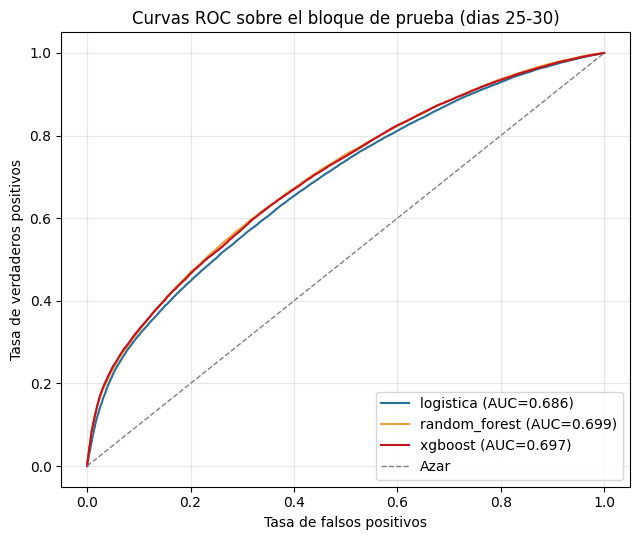

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for nombre, info in finalistas.items():
    fpr, tpr, _ = roc_curve(y_prueba, info["proba"])
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={tabla_prueba.loc[nombre, 'roc_auc']:.3f})",
            color=colores[nombre])
ax.plot([0, 1], [0, 1], "--", color="grey", linewidth=1, label="Azar")
ax.set(title="Curvas ROC sobre el bloque de prueba (dias 25-30)",
       xlabel="Tasa de falsos positivos", ylabel="Tasa de verdaderos positivos")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 9. Calibración

El tablero no muestra una clase sino una probabilidad. Con la tasa base desplazándose entre
períodos, un modelo entrenado en días con 44% de retrasos tiende a **subestimar** el riesgo en un
período con 53%. Conviene medirlo antes de exponer ese número al usuario.

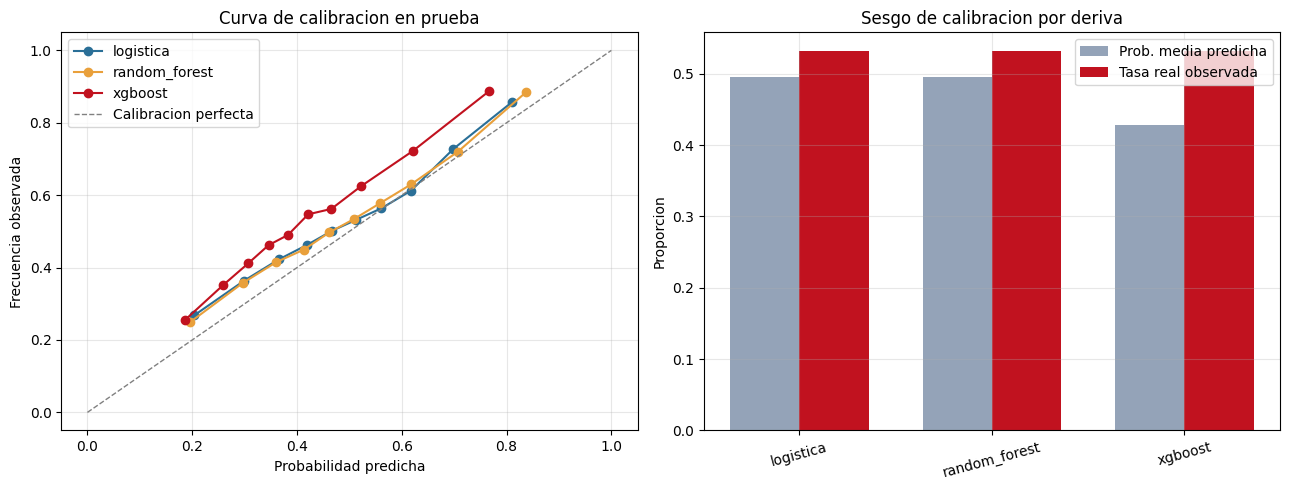

,Prob. media predicha,Tasa real observada,Brier
logistica,0.4957,0.5314,0.2236
random_forest,0.4956,0.5314,0.2195
xgboost,0.4277,0.5314,0.2292


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for nombre, info in finalistas.items():
    obs, pred = calibration_curve(y_prueba, info["proba"], n_bins=10, strategy="quantile")
    axes[0].plot(pred, obs, marker="o", label=nombre, color=colores[nombre])
axes[0].plot([0, 1], [0, 1], "--", color="grey", linewidth=1, label="Calibracion perfecta")
axes[0].set(title="Curva de calibracion en prueba", xlabel="Probabilidad predicha",
            ylabel="Frecuencia observada")
axes[0].legend()

resumen_cal = pd.DataFrame({
    nombre: {
        "Prob. media predicha": info["proba"].mean(),
        "Tasa real observada": y_prueba.mean(),
        "Brier": tabla_prueba.loc[nombre, "brier"],
    }
    for nombre, info in finalistas.items()
}).T
axes[1].bar(np.arange(len(resumen_cal)) - 0.18, resumen_cal["Prob. media predicha"],
            width=0.36, label="Prob. media predicha", color="#94A3B8")
axes[1].bar(np.arange(len(resumen_cal)) + 0.18, resumen_cal["Tasa real observada"],
            width=0.36, label="Tasa real observada", color="#C1121F")
axes[1].set_xticks(np.arange(len(resumen_cal)))
axes[1].set_xticklabels(resumen_cal.index, rotation=15)
axes[1].set(title="Sesgo de calibracion por deriva", ylabel="Proporcion")
axes[1].legend()

plt.tight_layout()
plt.show()
resumen_cal.round(4)

## 10. Modelo ganador

### Regla de selección

No se elige solo por AUC. Las diferencias entre familias son de milésimas, mientras que el tamaño
del artefacto difiere en dos órdenes de magnitud. Un modelo que hay que **reentrenar
periódicamente** por la deriva y que debe responder desde un contenedor tiene en el peso un costo
real: imagen más pesada, arranque más lento, despliegue más frágil.

La regla es explícita: gana el de mayor AUC, salvo que otro quede **dentro de 0,005 de AUC** y pese
menos de la mitad; en ese caso se prefiere el ligero. Un margen de 0,005 está dentro del ruido de
muestreo para un bloque de prueba de 107 mil filas.

In [16]:
MARGEN_AUC = 0.005

mejor_auc = tabla_prueba["roc_auc"].max()
candidatos = tabla_prueba[tabla_prueba["roc_auc"] >= mejor_auc - MARGEN_AUC]
ganador = candidatos["tamano_mb"].idxmin()
info_ganador = finalistas[ganador]

print(f"Empatados dentro de {MARGEN_AUC} de AUC: {list(candidatos.index)}")
print(f"Modelo elegido: {ganador}\n")
print(f"  ROC-AUC prueba  : {tabla_prueba.loc[ganador, 'roc_auc']:.4f}")
print(f"  Accuracy        : {tabla_prueba.loc[ganador, 'accuracy']:.4f}")
print(f"  F1              : {tabla_prueba.loc[ganador, 'f1']:.4f}")
print(f"  Umbral operativo: {info_ganador['umbral']:.2f}")
print(f"  Tamano artefacto: {info_ganador['tamano_mb']:.1f} MB")
print(f"\n  Ganancia de AUC sobre la linea base mas exigente: "
      f"{tabla_prueba.loc[ganador, 'roc_auc'] - tabla_base['roc_auc'].max():+.4f}")

Empatados dentro de 0.005 de AUC: ['random_forest', 'xgboost']
Modelo elegido: xgboost

  ROC-AUC prueba  : 0.6974
  Accuracy        : 0.6027
  F1              : 0.7082
  Umbral operativo: 0.27
  Tamano artefacto: 10.3 MB

  Ganancia de AUC sobre la linea base mas exigente: +0.0212


Dos diagnósticos del modelo elegido. La matriz de confusión está normalizada por fila, así que cada
celda se lee como "de los vuelos que realmente fueron X, qué proporción se clasificó como Y". La
importancia de variables usa la ganancia acumulada de cada una en los cortes del árbol: indica en
qué se apoya el modelo, no una relación causal.

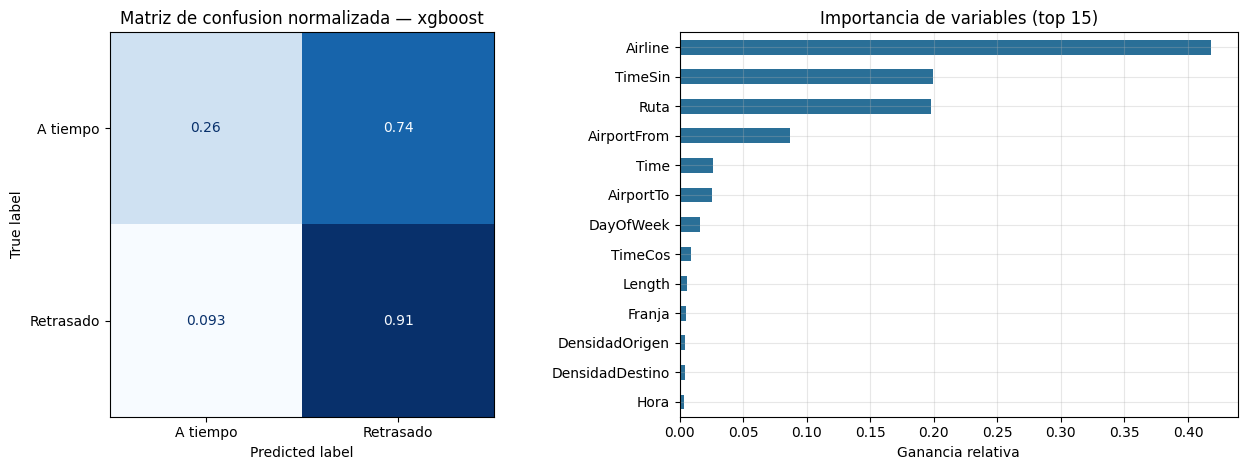

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

pred_ganador = (info_ganador["proba"] >= info_ganador["umbral"]).astype(int)
ConfusionMatrixDisplay.from_predictions(
    y_prueba, pred_ganador, display_labels=["A tiempo", "Retrasado"],
    cmap="Blues", colorbar=False, ax=axes[0], normalize="true",
)
axes[0].set_title(f"Matriz de confusion normalizada — {ganador}")
axes[0].grid(False)

pre_ganador = info_ganador["pipeline"].named_steps["preprocesamiento"]
modelo_final = info_ganador["pipeline"].named_steps["modelo"]

muestra = pre_ganador.transform(prueba.head(1))
if hasattr(muestra, "columns"):
    nombres = list(muestra.columns)
else:
    nombres = list(pre_ganador.named_steps["codificador"].get_feature_names_out())

if hasattr(modelo_final, "feature_importances_"):
    valores, etiqueta = modelo_final.feature_importances_, "Ganancia relativa"
else:
    valores, etiqueta = np.abs(modelo_final.coef_.ravel()), "|Coeficiente|"

importancias = pd.Series(valores, index=nombres).sort_values().tail(15)
importancias.plot(kind="barh", ax=axes[1], color="#2A6F97")
axes[1].set(title="Importancia de variables (top 15)", xlabel=etiqueta)

plt.tight_layout()
plt.show()

## 11. Recalibración

La sección 9 mostró que el ganador subestima el riesgo: predice una probabilidad media por debajo
de la tasa real del período de prueba. Como el tablero expone ese número al usuario, conviene
corregirlo.

La recalibración isotónica ajusta una función monótona entre la puntuación del modelo y la
frecuencia observada. Al ser monótona **no altera el ordenamiento**, así que el AUC se mantiene
prácticamente igual y lo que mejora es la calidad de la probabilidad.

El calibrador se ajusta sobre validación (días 20–24), un bloque que el modelo base no vio: usar los
mismos datos para entrenar y calibrar produciría un calibrador optimista. El costo es que el modelo
base se entrena con 20 días en vez de 25.

In [18]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

familia_ganadora = modeling.FAMILIAS[ganador]

base_calibracion = Pipeline([
    ("preprocesamiento", construir_preprocesador(familia_ganadora.preprocesamiento)),
    ("modelo", familia_ganadora.constructor(**dict(info_ganador["params"]))),
])
base_calibracion.fit(entrena, y_entrena)

calibrado = CalibratedClassifierCV(FrozenEstimator(base_calibracion), method="isotonic")
calibrado.fit(valida, y_valida)

proba_calibrada = calibrado.predict_proba(prueba)[:, 1]
metricas_calibradas = modeling.evaluar(y_prueba, proba_calibrada, info_ganador["umbral"])

comparacion_calibracion = pd.DataFrame({
    "Sin calibrar (0-24)": tabla_prueba.loc[ganador],
    "Calibrado (0-19 + isotonica en 20-24)": pd.Series(metricas_calibradas),
}).T[["roc_auc", "brier", "log_loss", "prob_media", "accuracy", "f1"]]
comparacion_calibracion["tasa_real"] = y_prueba.mean()
comparacion_calibracion.round(4)

,roc_auc,brier,log_loss,prob_media,accuracy,f1,tasa_real
Sin calibrar (0-24),0.6974,0.2292,0.6495,0.4277,0.6027,0.7082,0.5314
Calibrado (0-19 + isotonica en 20-24),0.6811,0.2252,0.6421,0.4968,0.5821,0.7047,0.5314


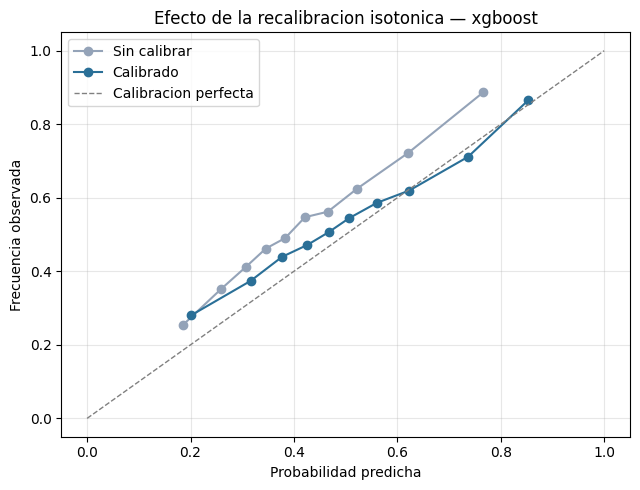

In [19]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for etiqueta, proba, color in [
    ("Sin calibrar", info_ganador["proba"], "#94A3B8"),
    ("Calibrado", proba_calibrada, "#2A6F97"),
]:
    obs, pred = calibration_curve(y_prueba, proba, n_bins=10, strategy="quantile")
    ax.plot(pred, obs, marker="o", label=etiqueta, color=color)
ax.plot([0, 1], [0, 1], "--", color="grey", linewidth=1, label="Calibracion perfecta")
ax.set(title=f"Efecto de la recalibracion isotonica — {ganador}",
       xlabel="Probabilidad predicha", ylabel="Frecuencia observada")
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# Se adopta el modelo calibrado solo si reduce el Brier sin costar AUC: si la
# recalibracion degradara el ordenamiento, el precio seria mayor que el beneficio.
mejora_brier = metricas_calibradas["brier"] < tabla_prueba.loc[ganador, "brier"]
costo_auc = tabla_prueba.loc[ganador, "roc_auc"] - metricas_calibradas["roc_auc"]

if mejora_brier and costo_auc < 0.005:
    modelo_produccion = calibrado
    proba_produccion = proba_calibrada
    calibrado_en_produccion = True
else:
    modelo_produccion = info_ganador["pipeline"]
    proba_produccion = info_ganador["proba"]
    calibrado_en_produccion = False

print(f"Brier sin calibrar : {tabla_prueba.loc[ganador, 'brier']:.4f}")
print(f"Brier calibrado    : {metricas_calibradas['brier']:.4f}")
print(f"Costo en AUC       : {costo_auc:+.4f}")
print(f"\nModelo que se lleva a produccion: "
      f"{ganador}{' + calibracion isotonica' if calibrado_en_produccion else ' (sin calibrar)'}")

Brier sin calibrar : 0.2292
Brier calibrado    : 0.2252
Costo en AUC       : +0.0164

Modelo que se lleva a produccion: xgboost (sin calibrar)


## 12. ¿Sirve `Flight`? Codificación por objetivo

La Entrega 1 excluyó `Flight` por ser un identificador. La retroalimentación señaló, con razón, que
la decisión merecía criterio: un one-hot sobre 6.543 niveles dispara la dimensionalidad, pero una
**codificación por objetivo** —sustituir el número de vuelo por su tasa histórica de retraso— podría
capturar justamente el efecto que el dataset perdió, porque un número de vuelo se asocia de forma
estable a una rotación de aeronave.

La hipótesis es buena y se pone a prueba. La codificación se ajusta **solo en entrenamiento**, con
suavizado hacia la media global para que un vuelo con tres apariciones no entre como si tuviera 67%
de riesgo.

In [21]:
from airlines_ml.features import RiesgoHistoricoVuelo

# ¿Es siquiera estable el riesgo por numero de vuelo entre periodos?
codif_entrena = RiesgoHistoricoVuelo().fit(entrena, y_entrena)
codif_valida = RiesgoHistoricoVuelo().fit(valida, y_valida)
comunes = codif_entrena.tabla_.index.intersection(codif_valida.tabla_.index)
estabilidad = np.corrcoef(codif_entrena.tabla_.loc[comunes],
                          codif_valida.tabla_.loc[comunes])[0, 1]

print(f"Numeros de vuelo distintos          : {entrena['Flight'].nunique():,}")
print(f"Observaciones por vuelo (promedio)  : {len(entrena) / entrena['Flight'].nunique():.0f}")
print(f"Vuelos presentes en ambos periodos  : {len(comunes):,}")
print(f"Correlacion del riesgo entre periodos: {estabilidad:.3f}")
print(f"Riesgo medio codificado: entrenamiento {codif_entrena.prior_:.4f} | "
      f"validacion {codif_valida.prior_:.4f}")

Numeros de vuelo distintos          : 6,543
Observaciones por vuelo (promedio)  : 53
Vuelos presentes en ambos periodos  : 6,274
Correlacion del riesgo entre periodos: 0.393
Riesgo medio codificado: entrenamiento 0.4100 | validacion 0.4814


In [22]:
# Ablation: misma configuracion ganadora de cada familia, con y sin la variable.
filas_ablation = []
for nombre, fila in mejores.set_index("familia").iterrows():
    familia = modeling.FAMILIAS[nombre]
    params = dict(modeling.muestrear_configuraciones(nombre, N_EXPERIMENTOS)[int(fila["corrida"]) - 1])

    aucs = {}
    for etiqueta, incluir in [("sin_flight", False), ("con_flight", True)]:
        pipe = Pipeline([
            ("preprocesamiento", construir_preprocesador(familia.preprocesamiento,
                                                         incluir_riesgo_vuelo=incluir)),
            ("modelo", familia.constructor(**params)),
        ])
        pipe.fit(entrena, y_entrena)
        aucs[etiqueta] = modeling.evaluar(y_valida, pipe.predict_proba(valida)[:, 1], 0.5)["roc_auc"]

    filas_ablation.append({"familia": nombre, **aucs,
                           "delta": aucs["con_flight"] - aucs["sin_flight"]})

tabla_ablation = pd.DataFrame(filas_ablation).set_index("familia")
tabla_ablation.round(4)

,sin_flight,con_flight,delta
familia,,,
logistica,0.6906,0.6871,-0.0035
random_forest,0.7073,0.7012,-0.0061
xgboost,0.7075,0.7015,-0.0060


In [23]:
# ¿El resultado depende del suavizado, o se sostiene en todo el rango?
familia_xgb = modeling.FAMILIAS["xgboost"]
params_xgb = dict(info_ganador["params"])

referencia = tabla_ablation.loc["xgboost", "sin_flight"]
filas_suavizado = []
for suavizado in [5, 20, 100, 500]:
    pre = construir_preprocesador("categorico", incluir_riesgo_vuelo=True)
    pre.set_params(riesgo_vuelo__suavizado=float(suavizado))
    pipe = Pipeline([("preprocesamiento", pre), ("modelo", familia_xgb.constructor(**params_xgb))])
    pipe.fit(entrena, y_entrena)
    auc = modeling.evaluar(y_valida, pipe.predict_proba(valida)[:, 1], 0.5)["roc_auc"]
    filas_suavizado.append({"suavizado": suavizado, "roc_auc": auc, "delta": auc - referencia})

tabla_suavizado = pd.DataFrame(filas_suavizado).set_index("suavizado")
print(f"AUC de referencia sin Flight: {referencia:.4f}\n")
print(tabla_suavizado.round(4).to_string())

with mlflow.start_run(run_name="ablation-flight"):
    mlflow.set_tags({"etapa": "ablation", "variable": "Flight"})
    mlflow.log_metrics({
        "estabilidad_entre_periodos": float(estabilidad),
        **{f"delta_{k}": float(v) for k, v in tabla_ablation["delta"].items()},
        **{f"delta_suavizado_{int(s)}": float(d)
           for s, d in tabla_suavizado["delta"].items()},
    })

AUC de referencia sin Flight: 0.7075

           roc_auc   delta
suavizado                 
5           0.7015 -0.0060
20          0.7015 -0.0060
100         0.7018 -0.0057
500         0.7024 -0.0051
🏃 View run ablation-flight at: http://54.173.162.16:5000/#/experiments/1/runs/7bf0c38257ae42bab0201031de8d5a02
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1


**La hipótesis no se sostiene, y los datos explican por qué.**

El riesgo por número de vuelo **no es estable entre períodos**: la correlación entre la tasa
aprendida en entrenamiento y la observada en validación es de apenas **0,39**. Con 53 observaciones
por número de vuelo, buena parte de esa tasa es ruido. Y lo que no es ruido arrastra la tasa base
del período de entrenamiento (0,41) hacia uno donde la tasa real es 0,48.

El resultado es que la variable **empeora las tres familias**, y el barrido de suavizado lo confirma:
el daño disminuye monótonamente a medida que se suaviza más, es decir, a medida que la variable se
convierte en una constante. Ese patrón es la firma de una variable que aporta ruido y sesgo, no
señal.

**`Flight` se mantiene fuera del modelo.** El efecto de rotación de aeronave que el dataset perdió
no se recupera con el identificador: sobrevivió el número, pero no el vínculo temporal que lo hacía
informativo. Recuperarlo exigiría datos que este dataset no tiene —matrícula de la aeronave y hora
real de llegada del vuelo previo—, y eso acota el techo de desempeño de toda la sección 8.

## 13. Punto de operación

El umbral que maximiza F1 no sirve como punto de operación. F1 premia el recall, y con una tasa base
del 53% eso lleva a marcar la gran mayoría de las franjas: una recomendación que señala casi todo el
itinerario no ayuda a priorizar nada.

El criterio realista es un **presupuesto de refuerzo**. Planeación no puede reforzar todo el
itinerario: puede asignar personal adicional, holgura de rotación o márgenes de conexión más amplios
a una fracción acotada de él. El umbral se fija entonces para marcar ese porcentaje, y la métrica
que importa pasa a ser la **precisión dentro del grupo reforzado** —de cada 100 franjas que se
refuercen, cuántas se habrían retrasado— junto al *lift* sobre la tasa base, que dice cuánto mejor
es usar el modelo que repartir los recursos al azar.

Los umbrales se calculan sobre los cuantiles de las predicciones en el período de **entrenamiento**,
nunca sobre prueba: fijar el corte con los datos de evaluación sería decidir mirando la respuesta.

In [24]:
proba_entrenamiento = modelo_produccion.predict_proba(entrena_completo)[:, 1]
proba_ganador = proba_produccion
tasa_base_prueba = y_prueba.mean()

fpr_tr, tpr_tr, cortes_tr = roc_curve(y_completo, proba_entrenamiento)
umbral_youden = float(cortes_tr[np.argmax(tpr_tr - fpr_tr)])

puntos = {
    "Maximo F1 (validacion)": info_ganador["umbral"],
    "Youden J": umbral_youden,
    "Refuerzo 30%": float(np.quantile(proba_entrenamiento, 0.70)),
    "Refuerzo 20%": float(np.quantile(proba_entrenamiento, 0.80)),
    "Refuerzo 10%": float(np.quantile(proba_entrenamiento, 0.90)),
}

filas = []
for etiqueta, umbral in puntos.items():
    metricas = modeling.evaluar(y_prueba, proba_ganador, umbral)
    filas.append({
        "Punto de operacion": etiqueta,
        "Umbral": umbral,
        "% franjas reforzadas": metricas["tasa_predicha"],
        "Precision": metricas["precision"],
        "Recall": metricas["recall"],
        "F1": metricas["f1"],
        "Lift": metricas["precision"] / tasa_base_prueba,
    })

tabla_operacion = pd.DataFrame(filas).set_index("Punto de operacion")
tabla_operacion.round(4)

,Umbral,% franjas reforzadas,Precision,Recall,F1,Lift
Punto de operacion,,,,,,
Maximo F1 (validacion),0.2700,0.8301,0.5808,0.9072,0.7082,1.0929
Youden J,0.4204,0.4510,0.6830,0.5797,0.6271,1.2853
Refuerzo 30%,0.4836,0.3124,0.7382,0.4339,0.5466,1.3891
Refuerzo 20%,0.5529,0.2087,0.7993,0.3139,0.4507,1.5041
Refuerzo 10%,0.6891,0.1029,0.8843,0.1713,0.2870,1.6642


figura guardada: docs/2nd_delivery/images/modelo_03_punto_operacion.png


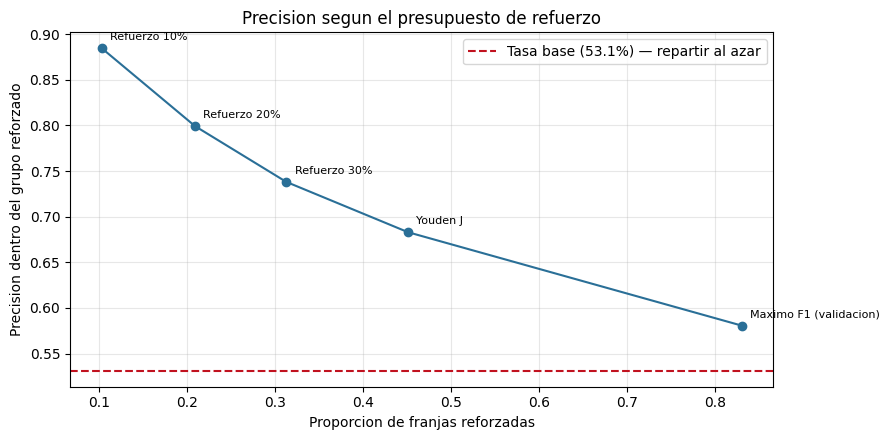

In [25]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(tabla_operacion["% franjas reforzadas"], tabla_operacion["Precision"],
        marker="o", color="#2A6F97")
for etiqueta, fila in tabla_operacion.iterrows():
    ax.annotate(etiqueta, (fila["% franjas reforzadas"], fila["Precision"]),
                textcoords="offset points", xytext=(6, 6), fontsize=8)
ax.axhline(tasa_base_prueba, color="#C1121F", linestyle="--",
           label=f"Tasa base ({tasa_base_prueba:.1%}) — repartir al azar")
ax.set(title="Precision segun el presupuesto de refuerzo",
       xlabel="Proporcion de franjas reforzadas", ylabel="Precision dentro del grupo reforzado")
ax.legend()
plt.tight_layout()
guardar(fig, "modelo_03_punto_operacion.png")
plt.show()

In [26]:
# Se adopta el presupuesto del 20% como punto de operacion del prototipo: es el
# que el tablero usa para decidir si un vuelo "supera el umbral". El de maximo F1
# se conserva en los metadatos como referencia de la busqueda.
UMBRAL_PRODUCCION = puntos["Refuerzo 20%"]
BANDA_ALTA = puntos["Refuerzo 10%"]

print(f"Umbral de produccion (presupuesto 20%): {UMBRAL_PRODUCCION:.4f}")
print(f"Corte de banda 'riesgo alto' (top 10%): {BANDA_ALTA:.4f}")
print(f"Precision esperada en el grupo reforzado: "
      f"{tabla_operacion.loc['Refuerzo 20%', 'Precision']:.1%} "
      f"(lift {tabla_operacion.loc['Refuerzo 20%', 'Lift']:.2f}x sobre la tasa base)")

Umbral de produccion (presupuesto 20%): 0.5529
Corte de banda 'riesgo alto' (top 10%): 0.6891
Precision esperada en el grupo reforzado: 79.9% (lift 1.50x sobre la tasa base)


## 14. Artefactos para el tablero

Se exportan tres cosas: el pipeline completo, los metadatos de operación (umbral, ventana de
entrenamiento, métricas) y los agregados descriptivos que alimentan las gráficas del tablero. Con
esto la API no necesita el CSV de 19 MB ni volver a calcular nada.

In [27]:
# El artefacto solo se sube para el ganador: registrar los tres duplicaria
# cientos de MB en el servidor sin aportar nada.
#
# serialization_format='cloudpickle' es necesario porque el pipeline incluye
# transformadores propios (DensidadProgramada, ACategoricas) que el formato skops
# por defecto no sabe serializar.
with mlflow.start_run(run_name=f"registro-{ganador}"):
    mlflow.set_tags({
        "familia": ganador,
        "etapa": "registro",
        "seleccionado": "true",
        "calibrado": str(calibrado_en_produccion),
    })
    mlflow.log_params({
        "umbral_produccion": UMBRAL_PRODUCCION,
        "banda_alta": BANDA_ALTA,
        "criterio_umbral": "presupuesto de refuerzo 20%",
    })
    mlflow.log_metrics({
        **tabla_prueba.loc[ganador].to_dict(),
        "precision_operativa": tabla_operacion.loc["Refuerzo 20%", "Precision"],
        "lift_operativo": tabla_operacion.loc["Refuerzo 20%", "Lift"],
    })
    try:
        mlflow.sklearn.log_model(
            modelo_produccion,
            name="modelo",
            input_example=prueba[CAMPOS_ENTRADA].head(3),
            serialization_format="cloudpickle",
            registered_model_name="riesgo-retraso-vuelos",
        )
        print("Artefacto registrado en MLflow como 'riesgo-retraso-vuelos'.")
    except Exception as exc:
        print(f"No se pudo subir el artefacto a MLflow ({type(exc).__name__}: {exc}).")
        print("El modelo queda igualmente en models/modelo_ganador.joblib.")

2026/09/05 16:58:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Successfully registered model 'riesgo-retraso-vuelos'.
2026/09/05 16:58:52 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: riesgo-retraso-vuelos, version 1
Created version '1' of model 'riesgo-retraso-vuelos'.


Artefacto registrado en MLflow como 'riesgo-retraso-vuelos'.
🏃 View run registro-xgboost at: http://54.173.162.16:5000/#/experiments/1/runs/ab6d892c91c14b8799dfc5932ad4f821
🧪 View experiment at: http://54.173.162.16:5000/#/experiments/1


Se guardan tres cosas en disco, que son las que consume el tablero:

| Archivo | Contenido |
|---|---|
| `models/modelo_ganador.joblib` | El pipeline completo: preprocesamiento y clasificador en un solo objeto |
| `models/metadata.json` | Umbral, bandas de riesgo, métricas y ventana de entrenamiento |
| `dashboard/data/vuelos.parquet` | Los datos agregables para las gráficas descriptivas |

Guardar el pipeline entero y no solo el clasificador es deliberado: si el tablero tuviera que
reconstruir las variables derivadas por su cuenta, cualquier diferencia mínima produciría
predicciones distintas a las del entrenamiento.

In [28]:
dir_modelos = RAIZ / "models"
dir_modelos.mkdir(exist_ok=True)
dir_datos_tablero = RAIZ / "dashboard" / "data"
dir_datos_tablero.mkdir(parents=True, exist_ok=True)

joblib.dump(modelo_produccion, dir_modelos / "modelo_ganador.joblib", compress=3)

metadatos = {
    "familia": ganador,
    "calibrado": calibrado_en_produccion,
    "umbral": round(UMBRAL_PRODUCCION, 4),
    "banda_alta": round(BANDA_ALTA, 4),
    "umbral_f1": round(info_ganador["umbral"], 4),
    "criterio_umbral": "presupuesto de refuerzo del 20% de las franjas",
    "campos_entrada": CAMPOS_ENTRADA,
    "ventana_entrenamiento": ("dias 0-19, con calibracion en 20-24"
                              if calibrado_en_produccion else "dias 0-24 del dataset"),
    "metricas_prueba": {k: round(v, 4)
                        for k, v in modeling.evaluar(y_prueba, proba_produccion,
                                                     UMBRAL_PRODUCCION).items()},
    "punto_operacion": tabla_operacion.loc["Refuerzo 20%"].round(4).to_dict(),
    "lineas_base": tabla_base[["roc_auc", "accuracy", "f1"]].round(4).to_dict(orient="index"),
    "tasa_base_entrenamiento": float(y_completo.mean()),
    "tasa_base_prueba": float(y_prueba.mean()),
    "run_id_mlflow": info_ganador["run_id"],
}
(dir_modelos / "metadata.json").write_text(json.dumps(metadatos, indent=2, ensure_ascii=False),
                                           encoding="utf-8")

print("Guardado en models/:")
for f in sorted(dir_modelos.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.0f} KB)")

Guardado en models/:
  .gitkeep  (0 KB)
  metadata.json  (1 KB)
  modelo_ganador.joblib  (10563 KB)


In [29]:
# La API agrega al vuelo sobre este parquet en vez de servir agregados
# precalculados: los cuatro filtros del tablero se combinan entre si y
# precalcular todas las combinaciones no es viable. Con codificacion de
# diccionario el archivo pesa una fraccion del CSV original.
from airlines_ml.features import agregar_derivadas

completo = agregar_derivadas(pd.concat([entrena_completo, prueba], ignore_index=True))

columnas_tablero = ["Airline", "AirportFrom", "AirportTo", "DayOfWeek", "Time",
                    "Length", "Franja", "Ruta", "DiaCalendario", OBJETIVO]
vuelos = completo[columnas_tablero].copy()
for columna in ["Airline", "AirportFrom", "AirportTo", "Franja", "Ruta"]:
    vuelos[columna] = vuelos[columna].astype("category")

ruta_parquet = dir_datos_tablero / "vuelos.parquet"
vuelos.to_parquet(ruta_parquet, index=False, compression="zstd")

print(f"Parquet del tablero: {ruta_parquet.stat().st_size / 1024**2:.1f} MB "
      f"({len(vuelos):,} filas)  frente a 18,3 MB del CSV original")
print(f"  {vuelos['AirportFrom'].nunique()} aeropuertos, "
      f"{vuelos['Airline'].nunique()} aerolineas, "
      f"{vuelos['Ruta'].nunique():,} rutas")

Parquet del tablero: 3.0 MB (539,379 filas)  frente a 18,3 MB del CSV original
  293 aeropuertos, 18 aerolineas, 4,190 rutas


In [30]:
resultados.to_csv(RAIZ / "docs" / "2nd_delivery" / "resultados_experimentos.csv", index=False)
print("Tabla completa de los 90 experimentos exportada a docs/2nd_delivery/")

Tabla completa de los 90 experimentos exportada a docs/2nd_delivery/


## 15. Conclusiones

Las observaciones detalladas están en
[`docs/2nd_delivery/reporte_entrega2.md`](../docs/2nd_delivery/reporte_entrega2.md). En resumen:

1. **Las tres familias superan las líneas base**, pero por márgenes modestos. El techo del problema
   está acotado por lo que el itinerario puede explicar: sin clima, estado de la aeronave ni retraso
   del vuelo precedente, buena parte de la varianza queda fuera de alcance.
2. **El boosting sobre categóricas nativas rinde mejor** que la codificación ordinal y que el modelo
   lineal, lo que era esperable con variables nominales de alta cardinalidad.
3. **La calibración se degrada por la deriva**: los modelos subestiman el riesgo en el período de
   prueba porque aprendieron una tasa base más baja. Es un argumento directo para recalibrar
   periódicamente, no solo reentrenar.
4. **El umbral debe fijarse explícitamente**. Dejarlo en 0,5 no corresponde a ningún punto de
   operación defendible cuando la tasa base se mueve.